<h1><center>Analyse de conversations patient-thérapeute sur la santé mentale</h1>

<quote><center>La santé mentale est un enjeu majeur de la santé publique. Ce projet vise, dans un pre-
mier temps, à exploiter le jeu de données pour comprendre les types de conversations et leur
structure, puis à analyser les sentiments des échanges afin de détecter les émotions et états
psychologiques des patients. Ensuite, il se concentre sur l’accès et le traitement des conversa-
tions, en résumant les échanges et en identifiant les schémas linguistiques récurrents. Enfin, il
prévoit le développement d’un système question-réponse, capable d’automatiser les interactions
et fournir des réponses.</quote>

<center><nav>
    <b>Auteur: LARROUX Logan</b><br><i>étudiant à l'université de Toulouse en licence Informatique</i><br><br>
    <a href="https://www.kaggle.com/datasets/thedevastator/nlp-mental-health-conversations">Données</a> |
    <a href="https://github.com/cypnet/Analyse-de-conversations-sur-la-sant-mentale-/tree/Logan">Github</a>
</nav>

In [4]:
# Import des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [5]:
data_path = './train.csv'
df = pd.read_csv(data_path)
print(f"Détails nombre de lignes/colonnes: {df.shape}")
print(f"\nDétails des colonnes: {df.columns.tolist()}")
print(f"\nAperçu des premières lignes:")
df.head()

Détails nombre de lignes/colonnes: (3512, 2)

Détails des colonnes: ['Context', 'Response']

Aperçu des premières lignes:


,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


<h3>Nettoyage des données (pré-traitement)</h3>

<h4>Cellules vides</h4> 

In [6]:
# On doit d'abord vérifier si il y a des cellules vides pour les deux colonnes
print("\nCellules vides (avant traitement): \n",df.isnull().sum())
df = df.dropna(subset=['Response', 'Context'])
print("\nCellules vides (après traitement): \n",df.isnull().sum())


Cellules vides (avant traitement): 
 Context     0
Response    4
dtype: int64

Cellules vides (après traitement): 
 Context     0
Response    0
dtype: int64


<h4>Doublons de cellules</h4>

In [7]:
# On vérifie ensuite si il y a des doublons de cellules
print("\nCellules dupliquées (avant traitement):",df.duplicated().sum())
df = df.drop_duplicates()
print("\nCellules dupliquées (après traitement):",df.duplicated().sum())


Cellules dupliquées (avant traitement): 760

Cellules dupliquées (après traitement): 0


In [8]:
# On vérifie que toute les cellules soient du type String et si ce n'est pas le cas (NaN) les remplacer par ''
df['Response'] = df['Response'].fillna('').astype(str)

# On regarde si les cellules Response et Context sont unique, si ce n'est pas le cas alors on supprimme les dupliquées
df = df.drop_duplicates(subset=['Response', 'Context'])

<h4>Passer tout les mots en minuscules</h4>
<p>Transformer tout les mots en minuscules nous permettra par la suite de les traiter plus facilement et éviter des situations telle que "toto" soit différent de "Toto".</p>

In [9]:
# compter les majuscules AVANT traitement
df['Response_upper'] = df['Response'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df['Context_upper'] = df['Context'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print("\nNombre de majuscules dans Response (avant):", df['Response_upper'].sum())
print("Nombre de majuscules dans Context (avant):", df['Context_upper'].sum())

# transformer le texte en minuscules
df['Response'] = df['Response'].str.lower()
df['Context'] = df['Context'].str.lower()


# compter les majuscules APRES traitement
df['Response_upper_after'] = df['Response'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))
df['Context_upper_after'] = df['Context'].apply(lambda x: sum(1 for c in str(x) if c.isupper()))

print("\nNombre de majuscules dans Response (après):", df['Response_upper_after'].sum())
print("Nombre de majuscules dans Context (après):", df['Context_upper_after'].sum())


Nombre de majuscules dans Response (avant): 61125
Nombre de majuscules dans Context (avant): 20485

Nombre de majuscules dans Response (après): 0
Nombre de majuscules dans Context (après): 0


<h4>Suppression des espaces insécables (non-breaking space)</h4>
<p>Un espace insécable est définit par le caractère spéciale Unicode <code>'\xa0'</code>. Celui-ci peut se retrouver dans nos données puisque le fichier csv a été récupérée depuis le web, il ne faut donc pas oublier à le retirer.</p>

In [10]:
df['Response'] = df['Response'].str.replace(r'\s+', ' ', regex=True)
df['Context'] = df['Context'].str.replace(r'\s+', ' ', regex=True)

<h4>Quand est-il de la ponctuation ?</h4>
<p>Le faire trop tôt posera problème lors de la lemmatisation que l'on fera un peu plus bas</p>

<h3>Tokenisation</h3>
<p>On va maitenant "découper" les mots de chaque cellules en <i>tokens</i>.<br>
Pour pouvoir les définir, on va utiliser la librairie <b>spaCy</b> qui est une version un peut plus moderne que nltk (The Natural Language Toolkit) </p>

<p><i>Il faut au préalable télécharger le modèle pour pouvoir l'utiliser:</i> <code>python3 -m spacy download en_core_web_sm
</code></p>

In [11]:
import spacy
nlp = spacy.load("en_core_web_sm") # On charge spaCy dans python

<h5>Attention !</h5>
<p>Ici on traite une grande quantité de données, tokeniser (si ça se dit...) les mots bêtements va prendre énormément de temps, puisque spacy va devoir exécuter tokenize sur chaque ligne </p>
<p> On va devoir utiliser <code>nlp.pipe()</code> pour traiter les cellules en batch</p>

In [12]:
docs_response = list(nlp.pipe(df["Response"].astype(str), batch_size=200))
docs_context = list(nlp.pipe(df["Context"].astype(str), batch_size=200))

df['Response_tokens'] = [[token.text for token in doc] for doc in docs_response]
df['Context_tokens'] = [[token.text for token in doc] for doc in docs_context]

In [13]:
# On affiche le nombre de token total
nb_tokens_response = df['Response_tokens'].apply(len).sum()
nb_tokens_context = df['Context_tokens'].apply(len).sum()
print(f"Nombre total de tokens: {nb_tokens_response + nb_tokens_context}")
print(f"\nNombre total de tokens dans Response: {nb_tokens_response}")
print(f"Nombre total de tokens dans Context: {nb_tokens_context}")

# On affiche les 5 tokens les plus fréquents dans Response et Context pour avoir un apperçu
resp_tokens = [token for tokens in df['Response_tokens'] for token in tokens]
cont_tokens = [token for tokens in df['Context_tokens'] for token in tokens]
print(f"\n5 tokens les plus fréquents dans Response: {Counter(resp_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Context: {Counter(cont_tokens).most_common(5)}")

Nombre total de tokens: 734153

Nombre total de tokens dans Response: 553023
Nombre total de tokens dans Context: 181130

5 tokens les plus fréquents dans Response: [('you', 22141), ('to', 20197), ('.', 19983), (',', 19421), ('the', 13262)]
5 tokens les plus fréquents dans Context: [('i', 12876), ('.', 10452), ('and', 5396), ('to', 5185), (',', 5044)]


<p><i>On remarque que la plupart des mots les plus utilisés ne sont que des mots dit "vide"...</i></p>

<h4>Ponctuations</h4>
<p>Cela nous permettra de trier les mots plus facilement plus tard.</p>

In [14]:
# Nombre de token "ponctuations" avant traitement
def count_ponctuation(tokens):
    return sum(1 for token in tokens if getattr(token, "is_punct", False))

nb_ponctuations_response = sum(count_ponctuation(doc) for doc in docs_response)
nb_ponctuations_context = sum(count_ponctuation(doc) for doc in docs_context)

print(f"\nNombre de tokens de ponctuation dans Response (avant traitement): {nb_ponctuations_response}")
print(f"Nombre de tokens de ponctuation dans Context (avant traitement): {nb_ponctuations_context}")

df["Response_tokens_no_punct"] = [
    [token.text for token in doc if not token.is_punct]
    for doc in docs_response
]

df["Context_tokens_no_punct"] = [
    [token.text for token in doc if not token.is_punct]
    for doc in docs_context
]

# Après suppression, avec la même logique, il ne devrait plus rester de tokens ponctuation
nb_ponctuations_response_no_punct = sum(
    count_ponctuation([token for token in doc if not token.is_punct]) for doc in docs_response
)
nb_ponctuations_context_no_punct = sum(
    count_ponctuation([token for token in doc if not token.is_punct]) for doc in docs_context
)

# Nombre de token de ponctuation après suppression
print(f"Nombre de tokens de ponctuation dans Response (après traitement): {nb_ponctuations_response_no_punct}")
print(f"Nombre de tokens de ponctuation dans Context (après traitement): {nb_ponctuations_context_no_punct}")


Nombre de tokens de ponctuation dans Response (avant traitement): 53128
Nombre de tokens de ponctuation dans Context (avant traitement): 18704
Nombre de tokens de ponctuation dans Response (après traitement): 0
Nombre de tokens de ponctuation dans Context (après traitement): 0


<h4>Suppression des StopWords</h4>
<p>Des <i>stopwords</i> (ou mots vides en français) sont des mots n'ayant pas de réelle significations. Ses mots sont souvents des adverbes, des pronoms ou encore des mots de liaisons.<br> 
<i>source: <a href="https://fr.wikipedia.org/wiki/Mot_vide">Wikipedia: Mot Vide</a> </i> </p>

In [15]:
df["Response_tokens_no_stop"] = [
    [token.text for token in doc if not token.is_stop]
    for doc in docs_response
]

df["Context_tokens_no_stop"] = [
    [token.text for token in doc if not token.is_stop]
    for doc in docs_context
]

# On compare les résultats de tokens avec tokens_no_stop
print(f"\n5 tokens les plus fréquents dans Response (avec stopwords): {Counter(resp_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Response (sans stopwords): {Counter([token for tokens in df['Response_tokens_no_stop'] for token in tokens]).most_common(5)}")
print(f"\n5 tokens les plus fréquents dans Context (avec stopwords): {Counter(cont_tokens).most_common(5)}")
print(f"5 tokens les plus fréquents dans Context (sans stopwords): {Counter([token for tokens in df['Context_tokens_no_stop'] for token in tokens]).most_common(5)}")


5 tokens les plus fréquents dans Response (avec stopwords): [('you', 22141), ('to', 20197), ('.', 19983), (',', 19421), ('the', 13262)]
5 tokens les plus fréquents dans Response (sans stopwords): [('.', 19983), (',', 19421), ('"', 2780), ('feel', 2121), ('help', 1863)]

5 tokens les plus fréquents dans Context (avec stopwords): [('i', 12876), ('.', 10452), ('and', 5396), ('to', 5185), (',', 5044)]
5 tokens les plus fréquents dans Context (sans stopwords): [('.', 10452), (',', 5044), ('?', 1844), ('feel', 991), ('like', 919)]


<h4>Lemmatisation</h4>
<p>Et enfin, il nous faut transformer les mots (tokens) en leurs forme de base, par exemple "running" deviendra "run", ou bien "better" deviendra "good". <br>
Cela permettra d'une part de diminuer drastiquement le nombre de tokens mais aussi de regrouper des mots qui sont similaires.</p>

<p>Tout ce qu'il y a été expliqué et traité au dessus peut se faire d'une traite dans la lemmatisation, en plus de d'autre traitements tel que:
<ul>
    <li>Les chiffres</li>
    <li>Les liens/URLs</li>
    <li>Les emails</li>
</ul>
Un traitement obligatoire quand on remarque qu'il existe ses anomalies dans les données.</p>

In [16]:
# renvoie oui ou non si il existe un token du type url, email, number
print(f"\nPrésence de tokens de type URL dans Response: {'Oui' if any(token.like_url for doc in docs_response for token in doc) else 'Non'}")
print(f"Présence de tokens de type URL dans Context: {'Oui' if any(token.like_url for doc in docs_context for token in doc) else 'Non'}")

print(f"\nPrésence de tokens de type Email dans Response: {'Oui' if any(token.like_email for doc in docs_response for token in doc) else 'Non'}")
print(f"Présence de tokens de type Email dans Context: {'Oui' if any(token.like_email for doc in docs_context for token in doc) else 'Non'}")

print(f"\nPrésence de tokens de type Number dans Response: {'Oui' if any(token.like_num for doc in docs_response for token in doc) else 'Non'}")
print(f"Présence de tokens de type Number dans Context: {'Oui' if any(token.like_num for doc in docs_context for token in doc) else 'Non'}")


Présence de tokens de type URL dans Response: Oui
Présence de tokens de type URL dans Context: Oui

Présence de tokens de type Email dans Response: Oui
Présence de tokens de type Email dans Context: Non

Présence de tokens de type Number dans Response: Oui
Présence de tokens de type Number dans Context: Oui


In [17]:
df["Response_clean"] = [
    [
        token.lemma_
        for token in doc
        if not token.is_stop        # stopwords
        and not token.is_punct      # ponctuation
        and not token.is_space      # espaces
        and not token.like_num      # chiffres
        and not token.like_url      # URLs
        and not token.like_email    # emails
        and token.is_alpha          # uniquement les tokens composés de lettres

    ]
    for doc in docs_response
]

df["Context_clean"] = [
    [
        token.lemma_
        for token in doc
        if not token.is_stop        # stopwords
        and not token.is_punct      # ponctuation
        and not token.is_space      # espaces
        and not token.like_num      # chiffres
        and not token.like_url      # URLs
        and not token.like_email    # emails
        and token.is_alpha          # uniquement les tokens composés de lettres
    ]
    for doc in docs_context
]

In [18]:
# On affiche maintenant le nombre de tokens après lemmatisation
nb_tokens_response_clean = df['Response_clean'].apply(len).sum()
nb_tokens_context_clean = df['Context_clean'].apply(len).sum()
print(f"Nombre total de tokens après lemmatisation: {nb_tokens_response_clean + nb_tokens_context_clean}")
print(f"\nNombre total de tokens dans Response après lemmatisation: {nb_tokens_response_clean}")
print(f"Nombre total de tokens dans Context après lemmatisation: {nb_tokens_context_clean}")

Nombre total de tokens après lemmatisation: 245592

Nombre total de tokens dans Response après lemmatisation: 192283
Nombre total de tokens dans Context après lemmatisation: 53309


In [19]:
# Apperçus du DataFrame après le traitement
df.head()

,Context,Response,Response_upper,Context_upper,Response_upper_after,Context_upper_after,Response_tokens,Context_tokens,Response_tokens_no_punct,Context_tokens_no_punct,Response_tokens_no_stop,Context_tokens_no_stop,Response_clean,Context_clean
0,i'm going through some things with my feelings...,"if everyone thinks you're worthless, then mayb...",10,10,0,0,"[if, everyone, thinks, you, 're, worthless, ,,...","[i, 'm, going, through, some, things, with, my...","[if, everyone, thinks, you, 're, worthless, th...","[i, 'm, going, through, some, things, with, my...","[thinks, worthless, ,, maybe, need, find, new,...","[going, things, feelings, ., barely, sleep, th...","[think, worthless, maybe, need, find, new, peo...","[go, thing, feeling, barely, sleep, think, wor..."
1,i'm going through some things with my feelings...,"hello, and thank you for your question and see...",43,10,0,0,"[hello, ,, and, thank, you, for, your, questio...","[i, 'm, going, through, some, things, with, my...","[hello, and, thank, you, for, your, question, ...","[i, 'm, going, through, some, things, with, my...","[hello, ,, thank, question, seeking, advice, ....","[going, things, feelings, ., barely, sleep, th...","[hello, thank, question, seek, advice, feeling...","[go, thing, feeling, barely, sleep, think, wor..."
2,i'm going through some things with my feelings...,first thing i'd suggest is getting the sleep y...,5,10,0,0,"[first, thing, i, 'd, suggest, is, getting, th...","[i, 'm, going, through, some, things, with, my...","[first, thing, i, 'd, suggest, is, getting, th...","[i, 'm, going, through, some, things, with, my...","[thing, suggest, getting, sleep, need, impact,...","[going, things, feelings, ., barely, sleep, th...","[thing, suggest, get, sleep, need, impact, thi...","[go, thing, feeling, barely, sleep, think, wor..."
3,i'm going through some things with my feelings...,therapy is essential for those that are feelin...,14,10,0,0,"[therapy, is, essential, for, those, that, are...","[i, 'm, going, through, some, things, with, my...","[therapy, is, essential, for, those, that, are...","[i, 'm, going, through, some, things, with, my...","[therapy, essential, feeling, depressed, worth...","[going, things, feelings, ., barely, sleep, th...","[therapy, essential, feel, depressed, worthles...","[go, thing, feeling, barely, sleep, think, wor..."
4,i'm going through some things with my feelings...,i first want to let you know that you are not ...,3,10,0,0,"[i, first, want, to, let, you, know, that, you...","[i, 'm, going, through, some, things, with, my...","[i, first, want, to, let, you, know, that, you...","[i, 'm, going, through, some, things, with, my...","[want, let, know, feelings, help, ., change, f...","[going, things, feelings, ., barely, sleep, th...","[want, let, know, feeling, help, change, feeli...","[go, thing, feeling, barely, sleep, think, wor..."


<p><i>On précise bien entendu que toute les étapes peuvent se résumer dans la lemmatisation, le but ici est de détailler toutes les étapes de traitement</i></p>

<h3>Analyse Statistique</h3>

<h4>Nombre de patients uniques</h4>

<p>Il n'y a pas vraiment de façon directe (ou du moins assez fiable) pour définir un patient d'un autre sans un identifiant, la seul façon ici serait de définir une cellule pour un patient et une cellule pour un thérapeute (<b>sans compter les doublons</b>). <br>
Une des suppositions que l'on peut faire serait que chaque cellules patients dupliquée serait un unique patient, celui-ci évoquant la même discussion avec différents thérapeutes. <br>
Cette solution peut fonctionner est très approximative, surtout pour les thérapeutes.</p>

In [20]:
# On compte le nombre de patients uniques dans context_clean
unique_patients = df['Context'].nunique()
print(f"\nNombre de patients uniques: {unique_patients}")


Nombre de patients uniques: 831


<h4>Nombre de thérapeutes uniques</h4>

In [21]:
# On compte le nombre de thérapeutes uniques
unique_therapeutes = df['Response'].nunique()
print(f"Nombre de thérapeutes uniques: {unique_therapeutes}")

Nombre de thérapeutes uniques: 2452


<h4>Distribution des conversations par thérapeute</h4>
<p>On cherche ici combien de conversations peut avoir un thérapeute avec un ou plusieurs patients. Or le problème ici est que, comme au dessus, on a pas d'ID pour les thérapeutes ni pour les patients, donc aucuns moyens de déterminer le nombre de conversations par thérapeutes. </p>

<h4>Nombre d'échanges moyen par conversation</h4>
<p>Ici, on cherche à voir le nombre de mots moyens par patients/thérapeutes</p>

In [22]:
# Nombre de mots moyens par patients
mean_context_w_stopwords = df['Context'].apply(len).mean()
mean_context_wo_stopwords = df['Context_tokens_no_stop'].apply(len).mean()
mean_context_w_lemmas = df['Context_clean'].apply(len).mean()
print(f"Nombre de mots moyens par patients (avec stopwords): {mean_context_w_stopwords:.2f}")
print(f"Nombre de mots moyens par patients (sans stopwords): {mean_context_wo_stopwords:.2f}")
print(f"Nombre de mots moyens par patients (avec lemmatisation): {mean_context_w_lemmas:.2f}")

print("") # <br>

# Nombre de mots moyens par thérapeutes
mean_response_w_stopwords = df['Response'].apply(len).mean()
mean_response_wo_stopwords = df['Response_tokens_no_stop'].apply(len).mean()
mean_response_w_lemmas = df['Response_clean'].apply(len).mean()
print(f"Nombre de mots moyens par thérapeutes (avec stopwords): {mean_response_w_stopwords:.2f}")
print(f"Nombre de mots moyens par thérapeutes (sans stopwords): {mean_response_wo_stopwords:.2f}")
print(f"Nombre de mots moyens par thérapeutes (avec lemmatisation): {mean_response_w_lemmas:.2f}")

Nombre de mots moyens par patients (avec stopwords): 289.70
Nombre de mots moyens par patients (sans stopwords): 26.47
Nombre de mots moyens par patients (avec lemmatisation): 19.40

Nombre de mots moyens par thérapeutes (avec stopwords): 1033.97
Nombre de mots moyens par thérapeutes (sans stopwords): 92.19
Nombre de mots moyens par thérapeutes (avec lemmatisation): 69.97


<p>On regarde <b>qui parle le plus entre les thérapeutes et les patients</b> et <b>le ratio</b></p>

In [23]:
# Avec stopwords
if mean_response_wo_stopwords > mean_context_wo_stopwords: 
    print("\nEn moyenne, les thérapeutes utilisent plus de mots que les patients (avec stopwords).")
    print(f"Les thérapeutes utilisent {(mean_context_w_stopwords / mean_response_w_stopwords)*100:.2f}% plus de mots que les patients (avec stopwords).")
else:
    print("\nEn moyenne, les patients utilisent plus de mots que les thérapeutes (avec stopwords).")
    print(f"Les patients utilisent {mean_context_w_stopwords / mean_response_w_stopwords*100:.2f}% plus de mots que les thérapeutes (avec stopwords).")

# Avec lemmatisation
if mean_response_w_lemmas > mean_context_w_lemmas: 
    print("\nEn moyenne, les thérapeutes utilisent plus de mots que les patients (avec lemmatisation).")
    print(f"Les thérapeutes utilisent {(mean_context_w_lemmas / mean_response_w_lemmas)*100:.2f}% plus de mots que les patients (avec lemmatisation).")
else:
    print("\nEn moyenne, les patients utilisent plus de mots que les thérapeutes (avec lemmatisation).")
    print(f"Les patients utilisent {mean_context_w_lemmas / mean_response_w_lemmas*100:.2f}% plus de mots que les thérapeutes (avec lemmatisation).")


En moyenne, les thérapeutes utilisent plus de mots que les patients (avec stopwords).
Les thérapeutes utilisent 28.02% plus de mots que les patients (avec stopwords).

En moyenne, les thérapeutes utilisent plus de mots que les patients (avec lemmatisation).
Les thérapeutes utilisent 27.72% plus de mots que les patients (avec lemmatisation).


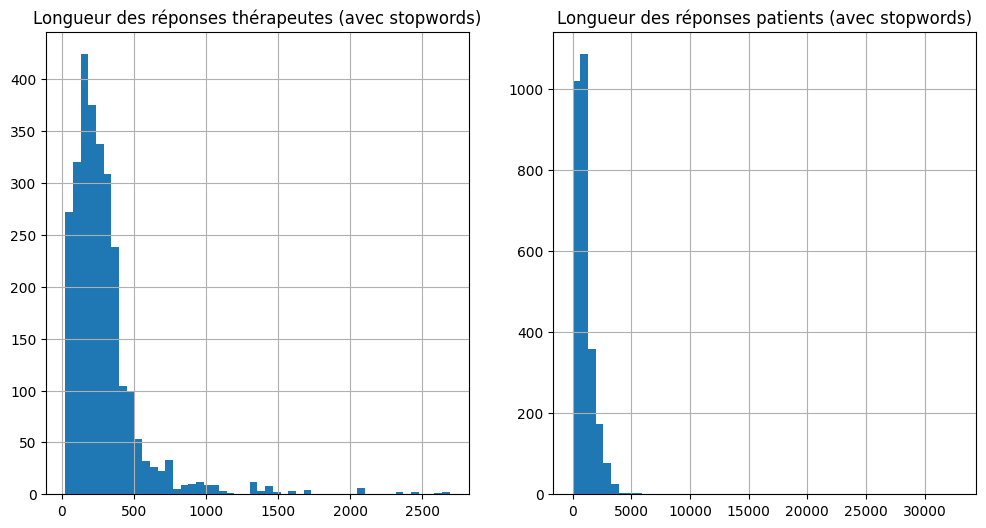

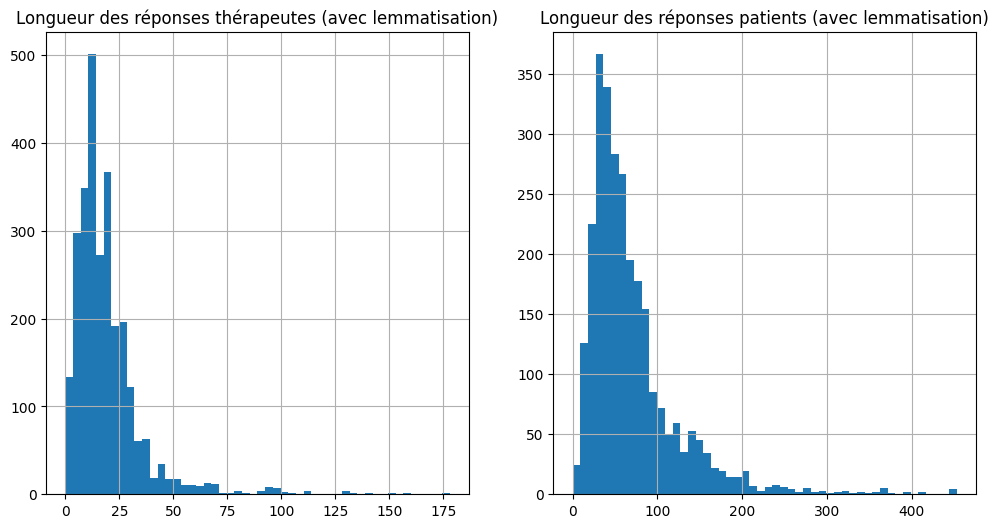

In [24]:
# Affichage de l'histogramme AVEC stopwords
plt.figure(figsize=(12, 6))

plt.subplot(121)
df['Context'].apply(len).hist(bins=50)
plt.title("Longueur des réponses thérapeutes (avec stopwords)")
plt.subplot(122)
df['Response'].apply(len).hist(bins=50)
plt.title("Longueur des réponses patients (avec stopwords)")
plt.show()

# Affichage de l'histogramme AVEC lemmatisation
plt.figure(figsize=(12, 6))
plt.subplot(121)
df['Context_clean'].apply(len).hist(bins=50)
plt.title("Longueur des réponses thérapeutes (avec lemmatisation)")
plt.subplot(122)
df['Response_clean'].apply(len).hist(bins=50)
plt.title("Longueur des réponses patients (avec lemmatisation)")
plt.show()

<h4>Mots les plus utilisés</h4>

In [25]:
# Liste des tokens de contexte_clean (patients)
context_tokens = [token for tokens in df['Context_clean'] for token in tokens if len(token) > 1]
# Liste des tokens de response_clean (thérapeutes)
response_tokens = [token for tokens in df['Response_clean'] for token in tokens if len(token) > 1]

# On créer un graphique avec la liste de tout les mots et leurs nombre d'apparition sur tout le corpus
all_tokens = context_tokens + response_tokens

# Nettoyage des tokens courts (contractions résiduelles comme "m" / "s" après suppression de ponctuation)
all_tokens = [token for token in all_tokens if len(token) > 1]

# Re-compter les tokens
all_token_counts = Counter(all_tokens)

# Top 3 mots les plus fréquents (mis en évidence en rouge)
top3_context = Counter(context_tokens).most_common(3)
top3_response = Counter(response_tokens).most_common(3)
top3 = Counter(context_tokens + response_tokens).most_common(3)

top3_context_tokens = [token for token, _ in top3_context]
top3_response_tokens = [token for token, _ in top3_response]

top3_tokens = [token for token, _ in top3]

# Préparer les données pour affichage (top 30 pour lisibilité)
top_n = 30
most_common_context = Counter(context_tokens).most_common(top_n)
most_common_response = Counter(response_tokens).most_common(top_n)
most_common = all_token_counts.most_common(top_n)

top_words_context = [token for token, _ in most_common_context]
top_counts_context = [count for _, count in most_common_context]

top_words_response = [token for token, _ in most_common_response]
top_counts_response = [count for _, count in most_common_response]

top_words = [token for token, _ in most_common]
top_counts = [count for _, count in most_common]

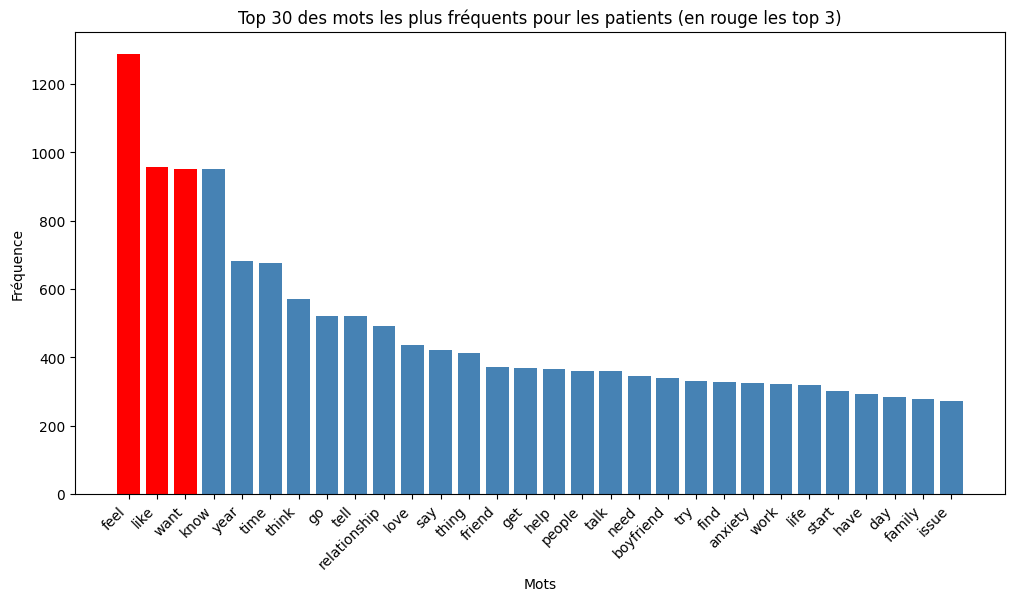

In [26]:
plt.figure(figsize=(12, 6))
bars = plt.bar(top_words_context, top_counts_context, color=['red' if token in top3_context_tokens else 'steelblue' for token in top_words_context])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les plus fréquents pour les patients (en rouge les top 3)')
plt.show()

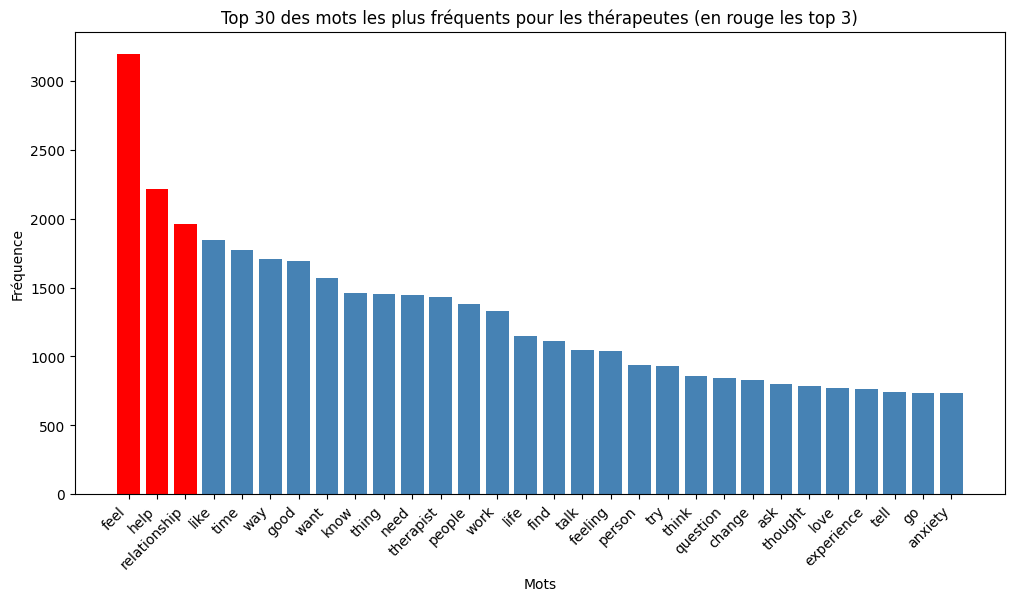

In [27]:
plt.figure(figsize=(12, 6))
bars = plt.bar(top_words_response, top_counts_response, color=['red' if token in top3_response_tokens else 'steelblue' for token in top_words_response])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les plus fréquents pour les thérapeutes (en rouge les top 3)')
plt.show()

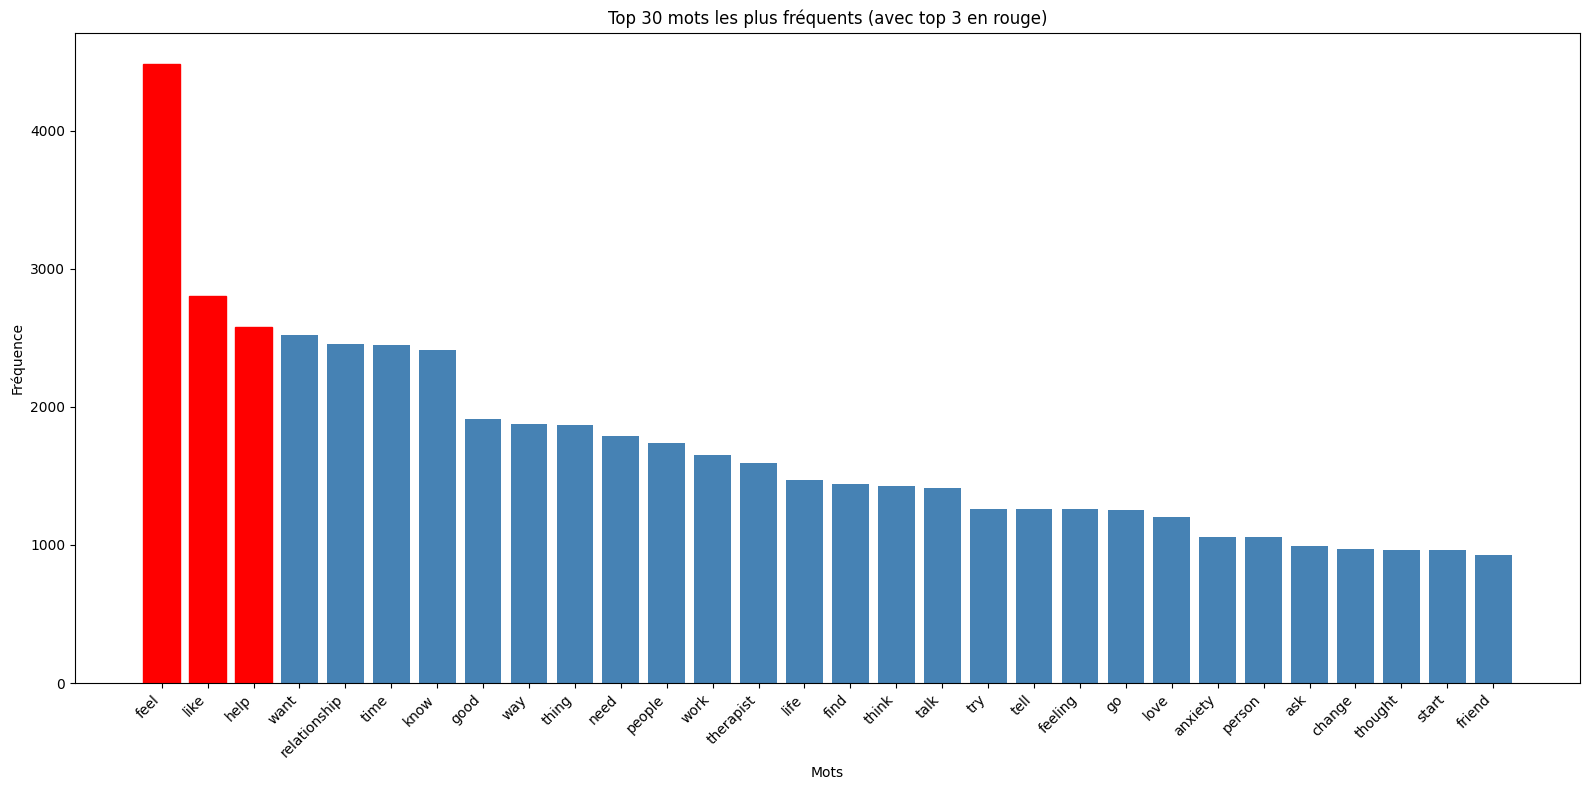

Top 3 mots les plus fréquents pour les patients:
- feel: 1288 fois
- like: 957 fois
- want: 950 fois

Top 3 mots les plus fréquents pour les thérapeutes:
- feel: 3197 fois
- help: 2214 fois
- relationship: 1963 fois

Trois mots les plus utilisés:
- feel: 4485 fois
- like: 2802 fois
- help: 2580 fois


In [28]:
plt.figure(figsize=(16, 8))
bars = plt.bar(top_words, top_counts, color=['red' if w in top3_tokens else 'steelblue' for w in top_words])

for i, (word, count) in enumerate(most_common):
    if word in top3_tokens:
        bars[i].set_color('red')

plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 mots les plus fréquents (avec top 3 en rouge)')
plt.tight_layout()
plt.show()

# Afficher les 3 mots les plus utilisés
print(f"Top 3 mots les plus fréquents pour les patients:")
for token, freq in top3_context:
    print(f'- {token}: {freq} fois')

print(f"\nTop 3 mots les plus fréquents pour les thérapeutes:")
for token, freq in top3_response:
    print(f'- {token}: {freq} fois')

print('\nTrois mots les plus utilisés:')
for token, freq in top3:
    print(f'- {token}: {freq} fois')

<p>On remarque ici que <i>feel</i> et <i>feeling</i> sont deux termes distincts, alors qu'après la lemmatisation ils auraient du se fusionner en un seul terme <i>feel</i>. Cela viens du fait que spaCy lemmatise différemment selon le <b>contexte grammatical</b> du mot. <br>
Quand feeling est utilisé comme nom (<i>"a feeling of anxiety"</i>), spaCy le garde tel quel au lieu de le ramener à <i>feel</i>.
Ensuite, <i>like</i> est un mot très ambigu en anglais. Il peut être une préposition/conjonction (<i>"I feel like"</i>), auquel cas c'est quasiment un mot vide. <br></p>

<h4>Corrélation entre patient et thérapeute</h4>
<p>La corrélation mesure, dans notre cas, le lien qu'il peut y avoir entre la longueur des phrases du patient et du thérapeute. Voir si quand le patient parle beaucoup le thérapeute aussi ou l'inverse.<br>
La valeur peut aller de -1 à 1, plus la valeur se rapproche de 1, plus le lien est réel. <br>
Dans notre cas, si la valeur se répproche de 1, cela signifie que plus le patient parle longtemps, plus le thérapeute repond longtemps. Inversement si la valeur se rapproche de -1, plus le patient parle, moins le thérapeute reponds longtemps.</p> 

In [29]:
df['context_len'] = df['Context_clean'].apply(len)
df['response_len'] = df['Response_clean'].apply(len)
print(df[['context_len', 'response_len']].corr())

              context_len  response_len
context_len      1.000000      0.047784
response_len     0.047784      1.000000


<p>On se retrouve donc avec une <b>corrélation proche de 0</b> (~0.05).<br>
Si on voulais traduire les résultats, cela signifie qu'un patient peut très bien parler longtemps, le thérapeute lui pourra répondre de façon courte.<br>
Les réponses des thérapeutes semblent donc relativement indépendantes, cela peut s'expliquer par l'utilisation de réponses standardisées ou des réponses très "robotiques".</p>

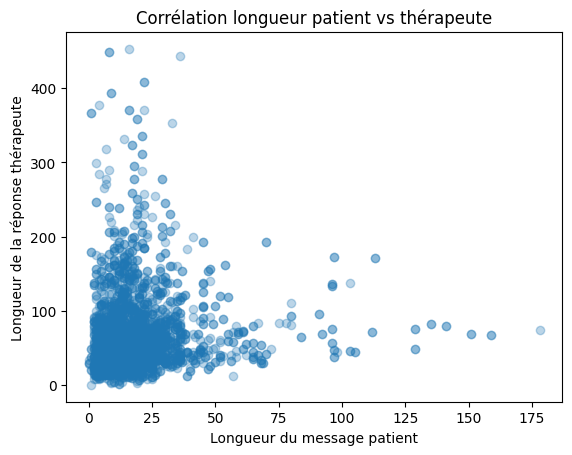

In [30]:
# Visualisation de la corrélation entre la longueur des messages patients et thérapeutes
plt.scatter(df["context_len"], df["response_len"], alpha=0.3)
plt.xlabel("Longueur du message patient")
plt.ylabel("Longueur de la réponse thérapeute")
plt.title("Corrélation longueur patient vs thérapeute")
plt.show()

<h3>Hapax legomena</h3>
<p>"Un hapax ou apax est un mot qui n'a qu'une seule occurence dans un corpus donnée."</p>
<i>source: <a href="https://fr.wikipedia.org/wiki/Hapax"> Hapax </a></i>

In [31]:
# On va faire un graphe des mots les moins fréquents pour les patients et les thérapeutes
# least_common n'existe pas dans Counter, on doit utiliser most_common avec l'indexe dans les négatifs pour commencer depuis la fin

# Bottom 3 mots les plus fréquents (mis en évidence en rouge)
bottom3_context = Counter(context_tokens).most_common()[-3:]
bottom3_response = Counter(response_tokens).most_common()[-3:]

bottom3_context_tokens = [token for token, _ in bottom3_context]
bottom3_response_tokens = [token for token, _ in bottom3_response]

bottom3 = bottom3_context + bottom3_response
bottom3_tokens = [token for token, _ in bottom3]

# Préparer les données pour affichage (bottom 30 pour lisibilité)
bottom_n = 30
least_common_context = Counter(context_tokens).most_common()[-bottom_n:]
least_common_response = Counter(response_tokens).most_common()[-bottom_n:]
least_common = Counter(all_token_counts).most_common()[-bottom_n:]

bottom_words_context = [token for token, _ in least_common_context]
bottom_counts_context = [count for _, count in least_common_context]

bottom_words_response = [token for token, _ in least_common_response]
bottom_counts_response = [count for _, count in least_common_response]

bottom_words = [token for token, _ in least_common]
bottom_counts = [count for _, count in least_common]

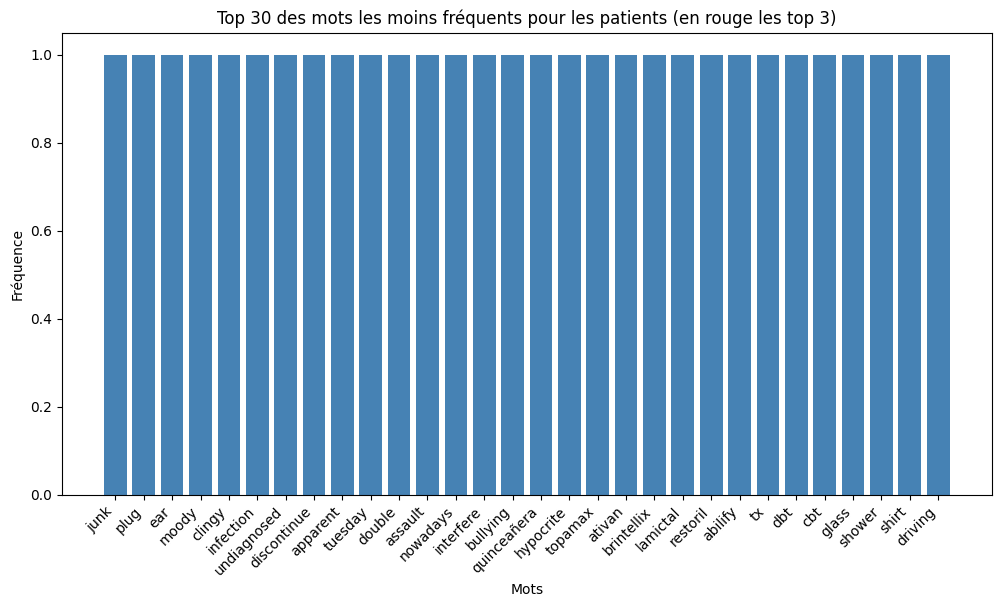

In [32]:
plt.figure(figsize=(12, 6))
bars = plt.bar(bottom_words_context, bottom_counts_context, color=['red' if token in top3_context_tokens else 'steelblue' for token in bottom_words_context])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les moins fréquents pour les patients (en rouge les top 3)')
plt.show()

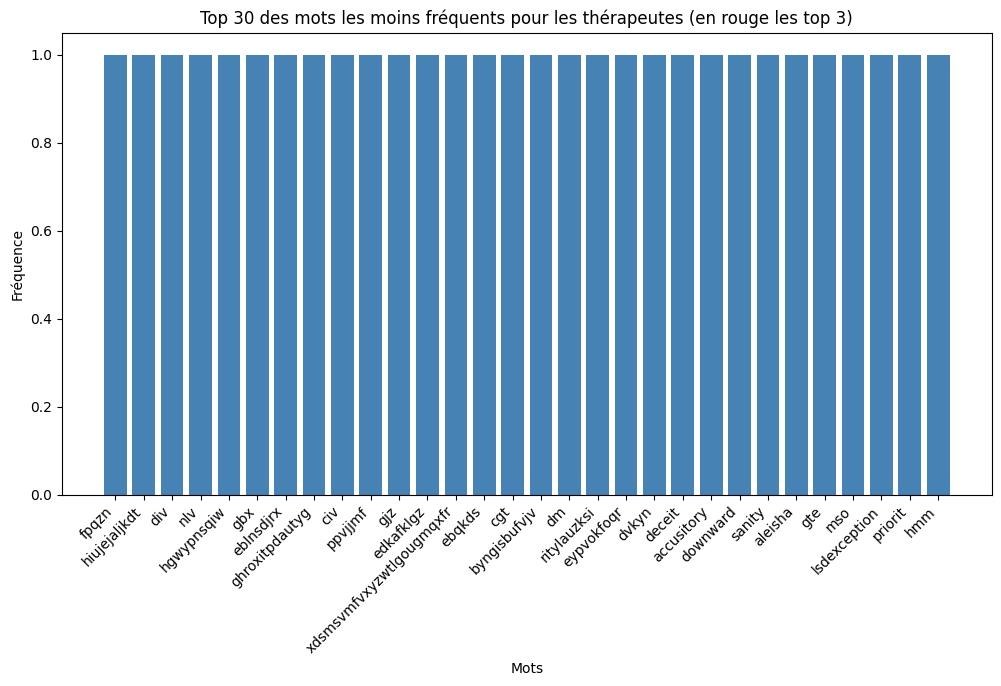

In [33]:
plt.figure(figsize=(12, 6))
bars = plt.bar(bottom_words_response, bottom_counts_response, color=['red' if token in top3_response_tokens else 'steelblue' for token in bottom_words_response])
plt.xticks(rotation=45, ha='right')
plt.xlabel('Mots')
plt.ylabel('Fréquence')
plt.title('Top 30 des mots les moins fréquents pour les thérapeutes (en rouge les top 3)')
plt.show()

<p>On remarque que la plupart des mots sont en fait du charabia...</p>

<h2>Résumé des résultats obtenues</h2>

In [34]:
# Nombre de patients/thérapeutes
print(f"Nombre de patients: {unique_patients}")
print(f"Nombre de thérapeutes: {unique_therapeutes}")

# Nombre de mots moyens par patients/thérapeutes
print("\nNombre de mots moyen conversé par patients:")
print(f"Sans lemmatisation: {mean_context_w_stopwords:.2f}")
print(f"Avec lemmatisation: {mean_context_w_lemmas}")

print("\nNombre de mots moyen conversé par thérapeutes:")
print(f"Sans lemmatisation: {mean_response_w_stopwords:.2f}")
print(f"Avec lemmatisation: {mean_response_w_lemmas:.2f}")

# Les mots les plus utilisés par les patients/thérapeutes/deux
print(f"\nTop 3 mots les plus fréquents pour les patients:")
for token, freq in top3_context:
    print(f'- {token}: {freq} fois')

print(f"\nTop 3 mots les plus fréquents pour les thérapeutes:")
for token, freq in top3_response:
    print(f'- {token}: {freq} fois')

print('\nTrois mots les plus utilisés:')
for token, freq in top3:
    print(f'- {token}: {freq} fois')

# Les mots les moins utilisés par les patients/thérapeutes/deux
print(f"\nTop 3 mots les moins fréquents pour les patients:")
for token, freq in bottom3_context:
    print(f'- {token}: {freq} fois')

print(f"\nTop 3 mots les moins fréquents pour les thérapeutes:")
for token, freq in bottom3_response:
    print(f'- {token}: {freq} fois')

Nombre de patients: 831
Nombre de thérapeutes: 2452

Nombre de mots moyen conversé par patients:
Sans lemmatisation: 289.70
Avec lemmatisation: 19.39919941775837

Nombre de mots moyen conversé par thérapeutes:
Sans lemmatisation: 1033.97
Avec lemmatisation: 69.97

Top 3 mots les plus fréquents pour les patients:
- feel: 1288 fois
- like: 957 fois
- want: 950 fois

Top 3 mots les plus fréquents pour les thérapeutes:
- feel: 3197 fois
- help: 2214 fois
- relationship: 1963 fois

Trois mots les plus utilisés:
- feel: 4485 fois
- like: 2802 fois
- help: 2580 fois

Top 3 mots les moins fréquents pour les patients:
- shower: 1 fois
- shirt: 1 fois
- driving: 1 fois

Top 3 mots les moins fréquents pour les thérapeutes:
- lsdexception: 1 fois
- priorit: 1 fois
- hmm: 1 fois


<h2>Analyse Lexicale</h2>

Maintenant que nous avons trié, traité et extrait toute les informations, il nous faut générer un **dictionnaire lexicale n-gram**.
Un n-gram est une séquence de $n$ mots consécutifs dans un texte, c'est une façon de capturer non seulement les mots isolés, mais aussi les **associations de mots fréquentes**.  
Par exemple:
- 1-gram (unigram): chaque mot est **isolé** -> ["anxiété", "sommeil" ,"stress"]
- 2-gram (bigram): les mots sont traité en **paires** -> ["anxiété sévère", "manque sommeil", "beaucoup stress"]
- 3-gram (trigram): en **triplet** -> ["Je me sens", "j'ai du mal", "depuis longtemps je"]
- ainsi de suite...

Dans notre travail, on va vouloir repérer des **formulations récurrentes** qui ont du sens:

| Type            | Exemple trouvé               | Conclusion                  |
|-                |-                             |-                            |
| Unigram         | "Anxiété" (freq: 342)        | Thème dominant              |
| Bigram          | "pensées négatives" (freq:87)| Expressions caractéristique |
| Trigram         | "j'arrive pas à" (freq:54)   | Patterne de détresse        |   

*source: https://www.geeksforgeeks.org/nlp/n-gram-in-nlp/*

In [35]:
from sklearn.feature_extraction.text import CountVectorizer

context_texts = df['Context_clean'].apply(lambda tokens: ' '.join(tokens))
response_texts = df['Response_clean'].apply(lambda tokens: ' '.join(tokens))

In [36]:
# On va maintenant créer une fonction qui nous donne les n-grams les plus fréquants
def get_ngram_freq(texts, ngram_range=(1, 1), top_n=20, label=""):
    """
    CountVectorizer initialise le transformeur avec les paramètres suivant:
        ngram_range -> le n-gram choisi dans la fonction
        max_features -> limite le vocabulaire aux 5000 n-grams les plus fréquents
    """
    vec = CountVectorizer(ngram_range=ngram_range, max_features=5000) 
    """
    fit_transform fait deux choses:
    fit (apprentissage): 
        analyse le texte, 
        construit un vocabulaire avec tout les n-grams uniques
        se limite à max_features n-grams les plus fréquents
    transform (transformation):
        convertit chaque texte en un vecteur numérique
        colonne de la matrice -> un n-gram
        ligne de la matrice -> ligne correspondant à un texte
        cellules -> fréquences d'apparition de n-gram dans ce texte        
    """
    X = vec.fit_transform(texts)

    freq = pd.DataFrame({
        'ngram': vec.get_feature_names_out(),
        'fréquence': X.toarray().sum(axis=0)
    }).sort_values('fréquence', ascending=False).head(top_n)

    print(f"\n Top {top_n} {label}:")
    print(freq.to_string(index=False))
    return freq

<h4>Résultats pour unigrams</h4>

In [37]:
uni_context  = get_ngram_freq(context_texts,  (1,1), top_n= 5, label="unigrams patients")
uni_response = get_ngram_freq(response_texts, (1,1), top_n=5, label="unigrams thérapeutes")


 Top 5 unigrams patients:
ngram  fréquence
 feel       1288
 like        957
 want        950
 know        950
 year        682

 Top 5 unigrams thérapeutes:
       ngram  fréquence
        feel       3197
        help       2214
relationship       1963
        like       1845
        time       1773


*On remarque que les résultats obtenus pour n = 1 sont les mêmes que ceux trouvés précédement*

#### **Mais alors comment déterminer le n des n-grams ?**
Il n'y a pas de réelles façons de déterminer un $n$, tout dépends du contexte et de son utilisation, une approche pour le choisir de façon raisonnée serait d'analyser la fréquence pour chaque $n$.  
Plus le $n$ est grand moins il y aura de groupes de mots, logique, sauf que notre but ici est d'analyser un pic drastique entre les $n$, si il est beaucoup trop grand, alors ça ne sert à rien d'aller plus loin.  
Ensuite on regarde le Hapax, qui correspond au pourcentage de n-grams qui n'apparaissent qu'une seul fois (vue et traité juste au dessus), si celui-ci excède 70/80%, une grande partie des mots sont unique et donc on ne peut rien en tirer de concluant.

In [38]:
# Fonction qui définit la fréquence moyenne pour chaque n-grams
def avg_ngram_freq(texts, max_n=5):
    results = []
    for n in range(1, max_n + 1):
        vec = CountVectorizer(ngram_range=(n, n))
        X = vec.fit_transform(texts)
        freqs = np.array(X.sum(axis=0)).flatten()
        results.append({
            'n': n,
            'nb_ngrams_uniques': len(freqs),
            'freq_moyenne': freqs.mean(),
            'pct_hapax': (freqs == 1).mean() * 100  # % de n-grams vus une seule fois
        })
    return pd.DataFrame(results)

context_texts = df['Context_clean'].apply(lambda t: ' '.join(t))
response_texts = df['Response_clean'].apply(lambda t: ' '.join(t))
context_stats= avg_ngram_freq(context_texts)
response_stats = avg_ngram_freq(response_texts)
print("Stats pour les patients: \n", context_stats)
print("\nStats pour les thérapeutes: \n", response_stats)


Stats pour les patients: 
    n  nb_ngrams_uniques  freq_moyenne  pct_hapax
0  1               2494     21.362470  14.795509
1  2              14145      3.572570  29.063273
2  3              16352      2.923251  32.693249
3  4              15754      2.863463  32.886886
4  5              14963      2.840139  32.807592

Stats pour les thérapeutes: 
    n  nb_ngrams_uniques  freq_moyenne  pct_hapax
0  1               8689     22.032685  26.297618
1  2              92287      2.044654  48.697000
2  3             127258      1.461205  57.896557
3  4             128751      1.422956  58.849252
4  5             127180      1.418965  58.888976


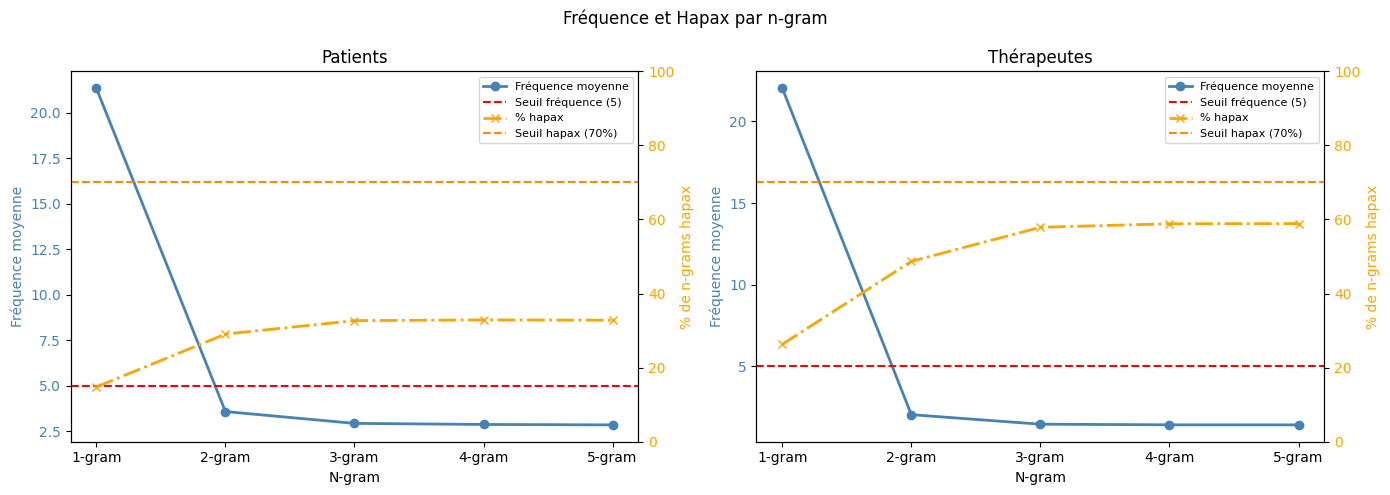

In [39]:
SEUIL_FREQ = 5
SEUIL_HAPAX = 70

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fréquence et Hapax par n-gram")

labels = [f"{n}-gram" for n in range(1, 6)]

for ax, stats, titre in zip(axes, [context_stats, response_stats], ["Patients", "Thérapeutes"]):
    ax2 = ax.twinx()  # second axe Y à droite, partage le même axe X

    # --- Axe gauche : fréquence moyenne ---
    ax.plot(labels, stats['freq_moyenne'], marker='o', color='steelblue',
            linewidth=2, label='Fréquence moyenne')
    ax.axhline(y=SEUIL_FREQ, color='red', linestyle='--', linewidth=1.5,
               label=f'Seuil fréquence ({SEUIL_FREQ})')
    ax.set_ylabel('Fréquence moyenne', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')

    # --- Axe droit : % hapax ---
    ax2.plot(labels, stats['pct_hapax'], marker='x', color='orange',
             linewidth=2, linestyle='-.', label='% hapax')
    ax2.axhline(y=SEUIL_HAPAX, color='darkorange', linestyle='--', linewidth=1.5,
                label=f'Seuil hapax ({SEUIL_HAPAX}%)')
    ax2.set_ylabel('% de n-grams hapax', color='orange')
    ax2.tick_params(axis='y', labelcolor='orange')
    ax2.set_ylim(0, 100)  # le % hapax va forcément de 0 à 100

    ax.set_title(titre)
    ax.set_xlabel('N-gram')

    # Légende combinée des deux axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

On remarque que à partie de $n = 1$ la fréquence a déjà drastiquement diminué, pour notre cas il est tout de même intéressant d'analyser les bigrames et trigrames, car on n'excède pas le seuil de % pour les Hapax.

<h4>Résultats pour bigrams</h4>

In [40]:
bi_context   = get_ngram_freq(context_texts,  (2,2), top_n = 5, label="bigrams patients")
bi_response  = get_ngram_freq(response_texts, (2,2), top_n = 5, label="bigrams thérapeutes")


 Top 5 bigrams patients:
        ngram  fréquence
    feel like        450
issue address         94
     year ago         91
  self esteem         65
    month ago         63

 Top 5 bigrams thérapeutes:
         ngram  fréquence
    sound like        434
     feel like        221
     good luck        169
 mental health        162
therapist help        154


<h4>Résultats pour trigrams</h4>

In [41]:
tri_context  = get_ngram_freq(context_texts,  (3,3), top_n = 5, label="trigrams patients")
tri_response = get_ngram_freq(response_texts, (3,3), top_n = 5, label="trigrams thérapeutes")


 Top 5 trigrams patients:
               ngram  fréquence
history sexual abuse         51
     low self esteem         50
  far everytime walk         48
   go couple therapy         48
    normal feel like         48

 Top 5 trigrams thérapeutes:
                     ngram  fréquence
      hello thank question         68
mental health professional         54
               dbh lpc ncc         51
          landwehr dbh lpc         51
        robin landwehr dbh         45


<h4>Visualisation des bigrams et trigrams</h4>

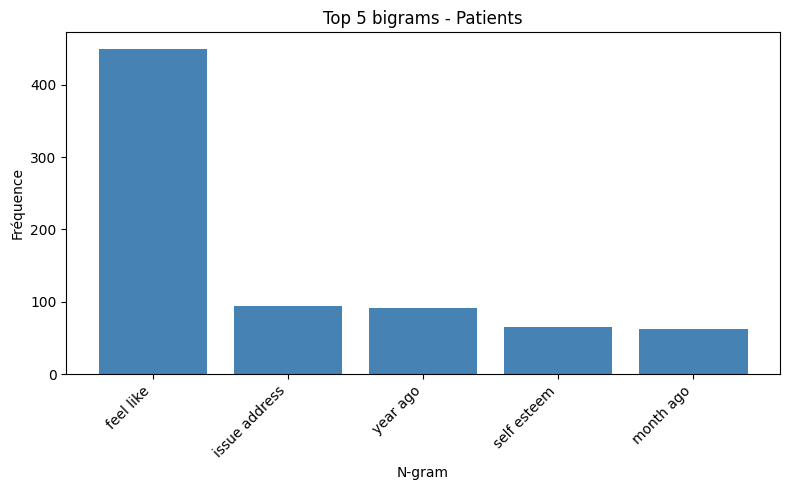

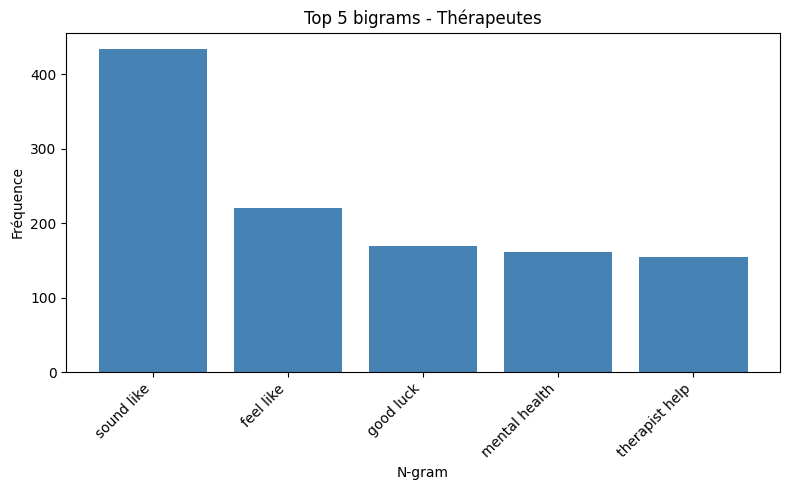

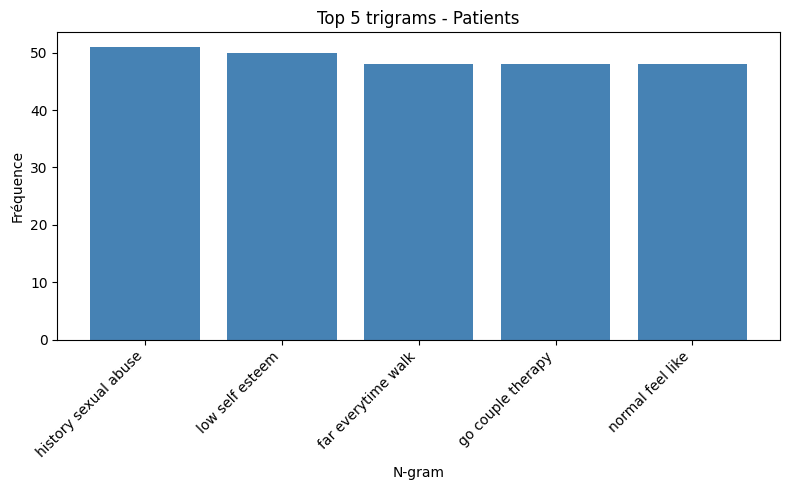

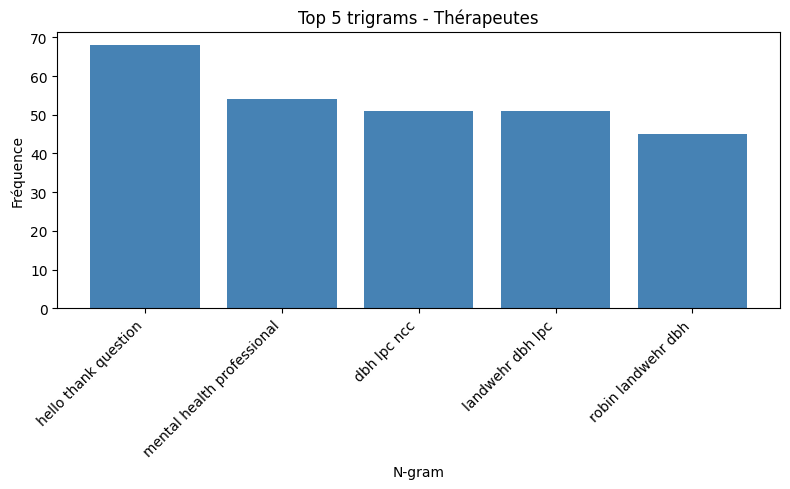

In [42]:
def plot_ngrams(freq_df, title):
    plt.figure(figsize=(8, 5))
    plt.bar(freq_df['ngram'], freq_df['fréquence'], color='steelblue')
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('N-gram')
    plt.ylabel('Fréquence')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_ngrams(bi_context,  "Top 5 bigrams - Patients")
plot_ngrams(bi_response, "Top 5 bigrams - Thérapeutes")
plot_ngrams(tri_context,  "Top 5 trigrams - Patients")
plot_ngrams(tri_response, "Top 5 trigrams - Thérapeutes")

Grâce aux bigrams et trigrams, on a déjà bien plus de contexte !  
Cela nous permettra par la suite de définir des patternes et des thèmes qui nous servirons sur le **topic modeling**. 

<h2>Modélisation et extraction de sujets (Topic Modeling)</h2>

<h3>Méthode 1: filtrage via un lexique métier défini manuellement</h3>

La première étape est une introduction.  
Ici, on va définir le dictionnaire à la main, avec pour chaque clée (un thème) une liste de mots qui correspondent à ce thème.

In [43]:
# TODO
# Initialisation du dictionnaire de lexique
lexique = {
    "anxiété":    ["anxiety", "anxious", "worry", "nervous", "panic", "fear", "stress"],
    "dépression": ["depression", "depressed", "sad", "hopeless", "empty", "worthless"],
    "sommeil":    ["sleep", "insomnia", "nightmare", "tired", "fatigue", "wake"],
    "trauma":     ["trauma", "abuse", "ptsd", "flashback", "violent", "assault"],
    "relations":  ["relationship", "family", "friend", "lonely", "isolate", "divorce"],
}

Maintenant qu'on a définit notre dictionnaire, on va trier les mots pour les mettres dans celui-ci.

In [44]:
# Fonction qui compte le nombre d'occurrences de mots liés à chaque thème dans les réponses des patients
def count_lexique_occurrences(tokens, lexique):
    counts = {theme: 0 for theme in lexique}
    for token in tokens:
        for theme, mots in lexique.items():
            if token in mots:
                counts[theme] += 1
    return counts

In [66]:
# On l'applique sur chaque lignes de contexte_clean et response_clean
df['theme_score_context'] = df['Context_clean'].apply(lambda tokens: count_lexique_occurrences(tokens, lexique))
df['theme_score_response'] = df['Response_clean'].apply(lambda tokens: count_lexique_occurrences(tokens, lexique))

# On affiche les mots qui reviennent le plus souvent pour chaque thème
for theme, mots in lexique.items():
    context_tokens_theme = [token for tokens in df['Context_clean'] for token in tokens if token in mots]
    response_tokens_theme = [token for tokens in df['Response_clean'] for token in tokens if token in mots]
    print(f"\nThème: {theme}")
    print(f"Top 3 mots les plus fréquents pour les patients: {Counter(context_tokens_theme).most_common(3)}")
    print(f"Top 3 mots les plus fréquents pour les thérapeutes: {Counter(response_tokens_theme).most_common(3)}")



Thème: anxiété
Top 3 mots les plus fréquents pour les patients: [('anxiety', 325), ('stress', 172), ('nervous', 86)]
Top 3 mots les plus fréquents pour les thérapeutes: [('anxiety', 732), ('fear', 429), ('stress', 305)]

Thème: dépression
Top 3 mots les plus fréquents pour les patients: [('depression', 233), ('depressed', 125), ('sad', 89)]
Top 3 mots les plus fréquents pour les thérapeutes: [('depression', 403), ('sad', 120), ('depressed', 54)]

Thème: sommeil
Top 3 mots les plus fréquents pour les patients: [('sleep', 145), ('nightmare', 46), ('tired', 45)]
Top 3 mots les plus fréquents pour les thérapeutes: [('sleep', 162), ('nightmare', 55), ('wake', 27)]

Thème: trauma
Top 3 mots les plus fréquents pour les patients: [('abuse', 122), ('violent', 29), ('flashback', 16)]
Top 3 mots les plus fréquents pour les thérapeutes: [('trauma', 215), ('abuse', 190), ('ptsd', 63)]

Thème: relations
Top 3 mots les plus fréquents pour les patients: [('relationship', 492), ('friend', 373), ('fami

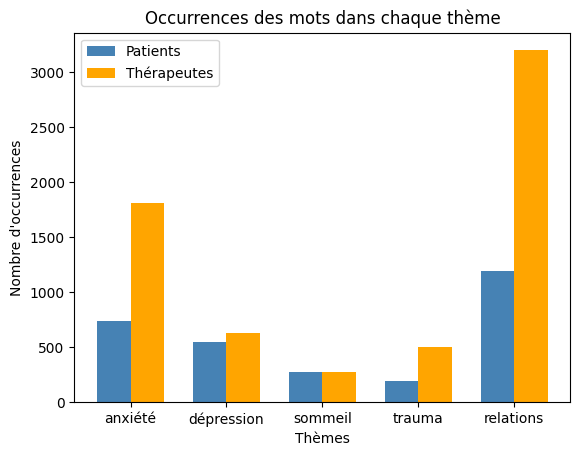

In [65]:
# On affiche en bar les scores pour patients et thérapeutes
plt.figsize=(12, 6)
themes = list(lexique.keys())
context_scores = {theme: df['theme_score_context'].apply(lambda x: x[theme]).sum() for theme in themes}
response_scores = {theme: df['theme_score_response'].apply(lambda x: x[theme]).sum() for theme in themes}
x = np.arange(len(themes))
width = 0.35
plt.bar(x - width/2, context_scores.values(), width, label='Patients', color='steelblue')
plt.bar(x + width/2, response_scores.values(), width, label='Thérapeutes', color='orange')
plt.xticks(x, themes)
plt.xlabel('Thèmes')
plt.ylabel('Nombre d\'occurrences')
plt.title('Occurrences des mots dans chaque thème')
plt.legend()
plt.show() 

On remarque depuis le graphe que les thérapeutes vont oser exprimer beaucoup plus souvent des termes liées à notre dictionnaire, en particulier les termes liés aux **relations familliale et amicale**, une conclusion qui est déjà très interessante mais **très limitée**.  
En effet, ici on utilise un dictionnaire extrèmement petit, beaucoup de mots ne sont pas traités ou sont tout simplement ignorés, par exemple *feeling* **n'appartient dans aucun thème**, ou bien un mot comme *down* pourrait être un terme lié à l'anxiété ou la dépression selon le contexte.  
Dans cette optique de vouloir aller plus loin, on va naturellement se pencher sur des méthodes qui sont bien plus aboutits et qui nous donnerons des résultats bien plus précis.

### Méthode 2: Vectorisation TF-IDF suivie d'un clustering

#### Tout d'abord, qu'est ce que le TF-IDF ?  

Viens de l'anglais *term frequency-inverse*, est une méthode de pondération utilisée en fouille de texte.  
Non seulement il calcule la "densité de mots-clés", il introduit une notion de **rareté** et de **spécificité**, cela permet d'évaluer l'importance d'un mot au sein d'un document.  

<u>Si on dépiote le terme TF-IDF:</u>
- **Term Frequency (TF)**: mesure la fréquence d'apparition d'un terme dans un document. Plus le mot est fréquent, plus le score TF est élevé.   
On le définit de façon mathématique de la sorte:  
$$
    tf_{i,j} = \frac{n_{i,j}}{\sum_k{n_{i,j}}}
$$ 
Avec:  
  - $i,j$ le nombre d'occurences du terme $i$ dans le document $j$
  - et $k$ le terme dans le document $j$

Si on devait s'arrêter là, cela signifirait que certains terme bien plus courant comme *"le"*, *"de*, ou *"et"* serait logiquement bien plus important. C'est pour cela qu'on introduit l'IDF.  

- **Inverse Document Frequency (IDF)**: Cette composante va pondérer le score en fonction de la rareté du mots dans **l'ensemble du web**. Un mot très commun aura un IDF faible et inversement pour un mot rare. On note l'équation pour l'IDF de cette façon:
$$
    idf(w) = \log({\frac{N}{df_t})}
$$
Avec:   
   - $w$ le poids des mots rares dans tout le document,  
   - $N$ le nombre total de documents  
   - et $df_t$ le nombre de documents contenant le mot $t$  

Si on combien les deux on a alors:
$$
    w_{i,j} = tf_{i,j} \times \log(\frac{N}{df_i})
$$
*source*:
- <a href= "https://fr.wikipedia.org/wiki/TF-IDF" > Wikipedia - TF-IDF </a>
- <a href="https://www.ledigitalpourtous.fr/2026/03/20/tf-idf-en-seo-comprendre-et-utiliser-cet-algorithme-pour-optimiser-vos-contenus/"> ledigitalpourtous - TF-IDF en SEO</a> 
- <a href="https://www.freecodecamp.org/news/how-to-process-textual-data-using-tf-idf-in-python-cd2bbc0a94a3" > freecodecomp - How to process textual data using TF-IDF in Python </a>

Dans notre cas, le traitement sera bien plus performant puisque l'on a déjà "supprimée" tout les stopwords et lemmatisé les mots. **L'IDF va mieux discriminer les termes et donc les scores seront plus significatifs**.

#### Préparation des textes  
Pour l'instant, on a les colonnes <code>Context_clean</code> et <code>Response_clean</code> qui contiennent la liste des tokens, sauf que TfidVectorizer attends des string, donc il faut les joindre avec <code>' '.join</code>

In [ ]:
df['Context_joined'] = df['Context_clean'].apply(lambda tokens: ' '.join(tokens))
df['Response_joined'] = df['Response_clean'].apply(lambda tokens: ' '.join(tokens))
df[['Context_joined', 'Response_joined']].head()

,Context_joined,Response_joined
0,go thing feeling barely sleep think worthless ...,think worthless maybe need find new people han...
1,go thing feeling barely sleep think worthless ...,hello thank question seek advice feeling worth...
2,go thing feeling barely sleep think worthless ...,thing suggest get sleep need impact think feel...
3,go thing feeling barely sleep think worthless ...,therapy essential feel depressed worthless wor...
4,go thing feeling barely sleep think worthless ...,want let know feeling help change feeling chan...


#### Vectorisation TF-IDF

In [ ]:
# TODO

#### Clustering

### Méthode 3: Utilisation Word Embedding couplé à un clustering

In [47]:
# TODO

### Méthode 4: Entrainement d'un modèle LDA

In [48]:
# TODO